# Bibliotecas

In [229]:
import os
import yaml
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import numpy as np
import torch
import random
import tkinter as tk
import torch
import shutil

from tkinter import filedialog
from sahi import AutoDetectionModel
from collections import Counter
from ultralytics import YOLO
from matplotlib.lines import Line2D
from sahi.predict import get_sliced_prediction

# Baixando Arquivos

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("snehilsanyal/construction-site-safety-image-dataset-roboflow")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3


# Localizando Pastas

In [ ]:
print(f"O path fornecido é: {path}")

def find_train_folder(base_path):
    for root, dirs, files in os.walk(base_path):
        if 'train' in dirs and 'labels' in os.listdir(os.path.join(root, 'train')):
            return os.path.join(root, 'train')
    return None

real_train_path = find_train_folder(path)

if real_train_path:
    print(f"✅ Sucesso! A pasta de treino real é: {real_train_path}")
    # Atualizando o caminho base para o script
    base_data_path = os.path.dirname(real_train_path)
else:
    print("❌ Não encontramos a pasta 'train/labels'. Vamos listar o que tem no diretório:")
    print(os.listdir(path))

O path fornecido é: C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3
✅ Sucesso! A pasta de treino real é: C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3\css-data\train


# Auditoria dos Dados

🔍 Analisando... isso pode levar alguns segundos.


C:\Users\Maiquel\AppData\Local\Temp\ipykernel_17716\3678547624.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x='Quantidade', y='Classe', palette='magma')


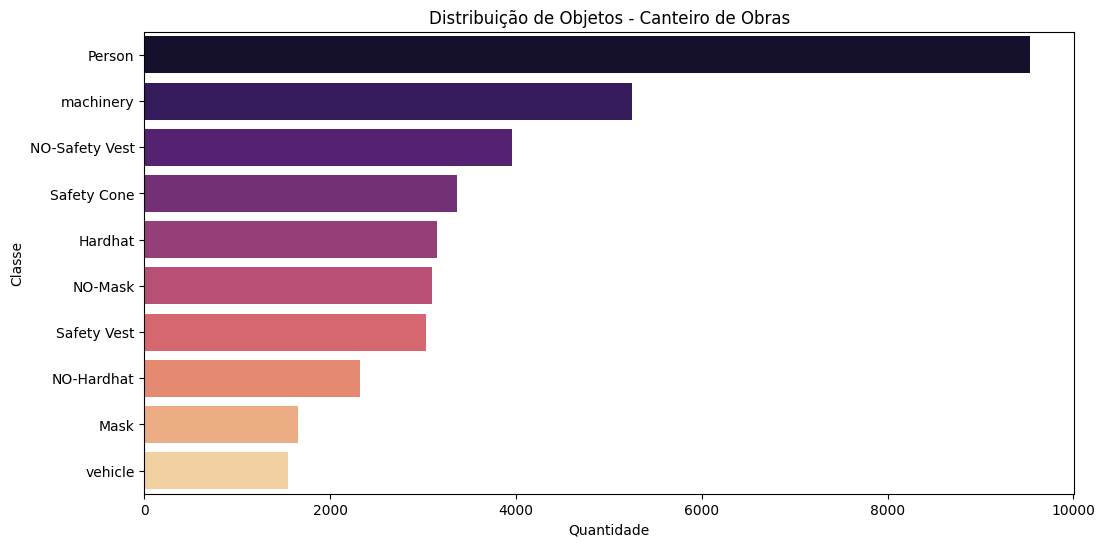


📊 Resumo Numérico:
           Classe  Quantidade
2          Person        9532
7       machinery        5247
5  NO-Safety Vest        3962
8     Safety Cone        3366
0         Hardhat        3145
1         NO-Mask        3097
6     Safety Vest        3033
4      NO-Hardhat        2317
3            Mask        1651
9         vehicle        1545


In [ ]:
target_path = base_data_path if 'base_data_path' in locals() else path

# Definição do mapa de classes (ID -> Nome)
class_map = {
    0: 'Hardhat',
    1: 'Mask',
    2: 'NO-Hardhat',
    3: 'NO-Mask',
    4: 'NO-Safety Vest',
    5: 'Person',
    6: 'Safety Cone',
    7: 'Safety Vest',
    8: 'machinery',
    9: 'vehicle'
}

def analyze_labels_v2(dataset_path, split):
    possible_paths = [
        os.path.join(dataset_path, split, 'labels'),
        os.path.join(dataset_path, 'css-data', split, 'labels'),
    ]

    label_path = None
    for p in possible_paths:
        if os.path.exists(p):
            label_path = p
            break

    counts = Counter()
    if not label_path:
        print(f"⚠️ Pasta de labels não encontrada para: {split}")
        return counts

    for label_file in os.listdir(label_path):
        if label_file.endswith('.txt'):
            with open(os.path.join(label_path, label_file), 'r') as f:
                for line in f:
                    try:
                        class_id = int(line.split()[0])
                        counts[class_id] += 1
                    except:
                        continue
    return counts

# Executar a contagem
print("🔍 Analisando... isso pode levar alguns segundos.")
train_counts = analyze_labels_v2(target_path, 'train')

if not train_counts:
    print("❌ Erro: Nenhuma etiqueta foi encontrada. Verifique se o dataset foi baixado corretamente.")
else:
    # Criar DataFrame e Gráfico
    df_counts = pd.DataFrame([
        {'Classe': class_map.get(k, f'Unknown-{k}'), 'Quantidade': v}
        for k, v in train_counts.items()
    ])

    df_counts = df_counts.sort_values(by='Quantidade', ascending=False)

    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_counts, x='Quantidade', y='Classe', palette='magma')
    plt.title('Distribuição de Objetos - Canteiro de Obras')
    plt.show()

    print("\n📊 Resumo Numérico:")
    print(df_counts)

# Organização e validação das fotos

In [ ]:
target_path = r'C:\Users\Maiquel\.cache\kagglehub\datasets\snehilsanyal\construction-site-safety-image-dataset-roboflow\versions\3\css-data'

# Define onde salvar o arquivo YAML
yaml_path = os.path.join(os.getcwd(), 'seguranca.yaml')


data_config = {
    'train': os.path.join(target_path, 'train', 'images'),
    'val': os.path.join(target_path, 'valid', 'images'),
    'test': os.path.join(target_path, 'test', 'images'),
    'nc': 10,
    'names': [class_map[i] for i in range(10)]
}

# Salva o arquivo no Windows
with open(yaml_path, 'w') as f:
    yaml.dump(data_config, f, default_flow_style=False)

print(f"✅ Arquivo de configuração criado em: {yaml_path}")

✅ Arquivo de configuração criado em: c:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Segurança_do_Trabalho\seguranca.yaml


# Treinamento do Modelo

In [ ]:
model = YOLO('yolov8n.pt')

print("🚀 Iniciando o treinamento na sua RTX 3050...")

# Iniciar o treinamento especializado
results = model.train(
    data='seguranca.yaml',
    epochs=50,                # Número de épocas
    imgsz=640,                # Resolução das imagens
    batch=8,                  # Sugestão: 8 é mais seguro para os 6GB de VRAM da sua placa
    name='seguranca_obra_v1', 
    device=0                  
)

🚀 Iniciando o treinamento na sua RTX 3050...
New https://pypi.org/project/ultralytics/8.4.10 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.9  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=seguranca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.9

# Matriz de Confusão e Curvas de Treinamento

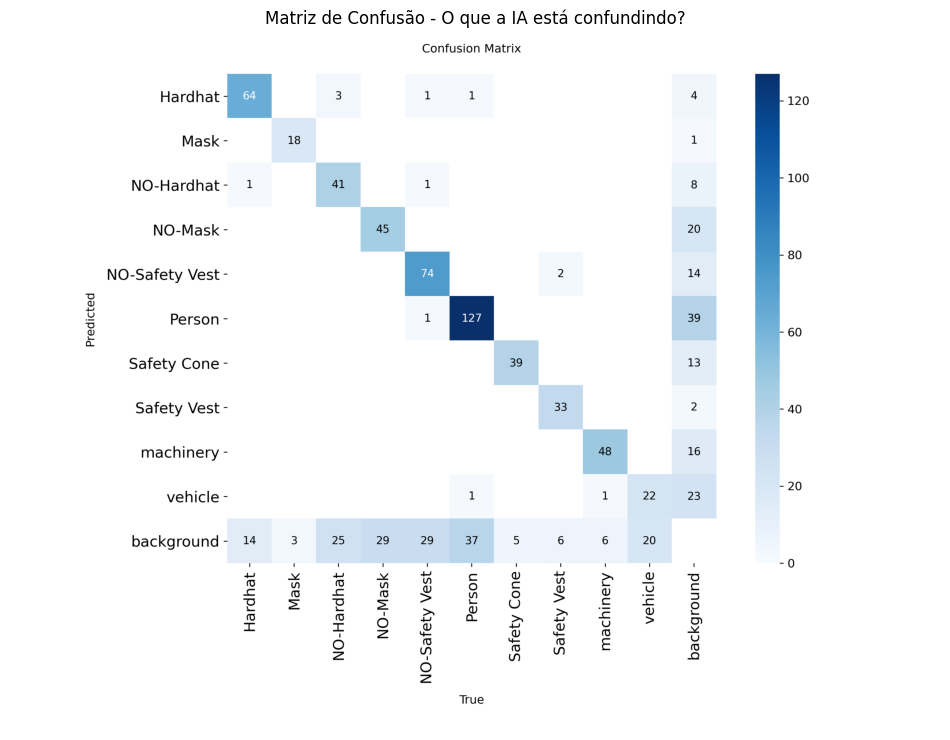

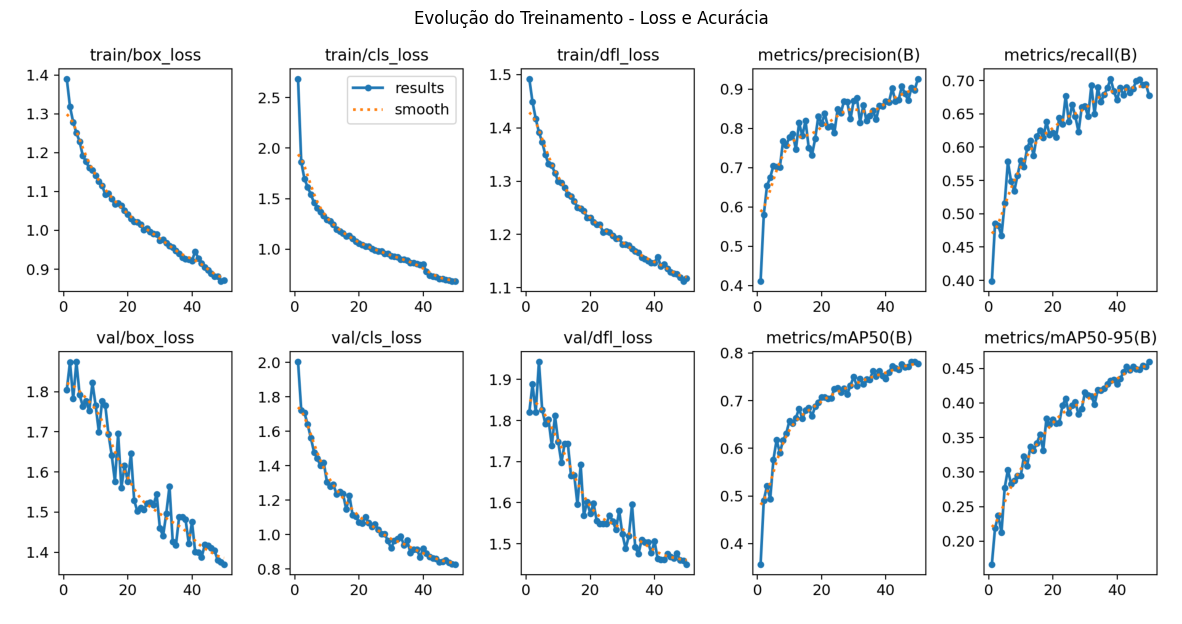

In [ ]:
# Definir o caminho onde os resultados foram salvos
res_path = r'C:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Seguranca_do_Trabalho\runs\detect\seguranca_obra_v1'

# Mostrar a Matriz de Confusão
plt.figure(figsize=(12, 10))
img_matrix = mpimg.imread(os.path.join(res_path, 'confusion_matrix.png'))
plt.imshow(img_matrix)
plt.title("Matriz de Confusão - O que a IA está confundindo?")
plt.axis('off')
plt.show()

# Mostrar os gráficos de treino (Loss e mAP)
plt.figure(figsize=(15, 10))
img_results = mpimg.imread(os.path.join(res_path, 'results.png'))
plt.imshow(img_results)
plt.title("Evolução do Treinamento - Loss e Acurácia")
plt.axis('off')
plt.show()

# Fine-Tuning

In [ ]:
# Carregar os pesos que já são bons (o melhor do treino anterior)
# Isso garante que não começamos do zero, mas do ponto mais inteligente
res_path_v1 = r'C:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Seguranca_do_Trabalho\runs\detect\seguranca_obra_v1\weights\best.pt'

modelo_pro = YOLO(res_path_v1)

# iniciar o Treinamento da V2 Pro
# Usando as configurações que sua RTX 3050 de 6GB aguentou (batch 8)
results_v2 = modelo_pro.train(
    data='seguranca.yaml',       # Dados de treino
    epochs=100,
    lr0=0.001,                   # Aprende mais devagar para não "estragar" o que já sabe
    patience=20,                 # Para sozinho se não melhorar mais
    imgsz=640,
    batch=8,                     # Mantendo o batch que funcionou bem
    augment=True,                # Ativa o "treino pesado" com distorções de imagem
    name='seguranca_obra_v2_pro',   # Nome do Modelo
    device=0
)

Ultralytics 8.4.10  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=seguranca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=C:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Segurana_do_Trabalho\runs\detect\seguranca_obra_v1\weights\best.pt

# Avaliação do Modelo

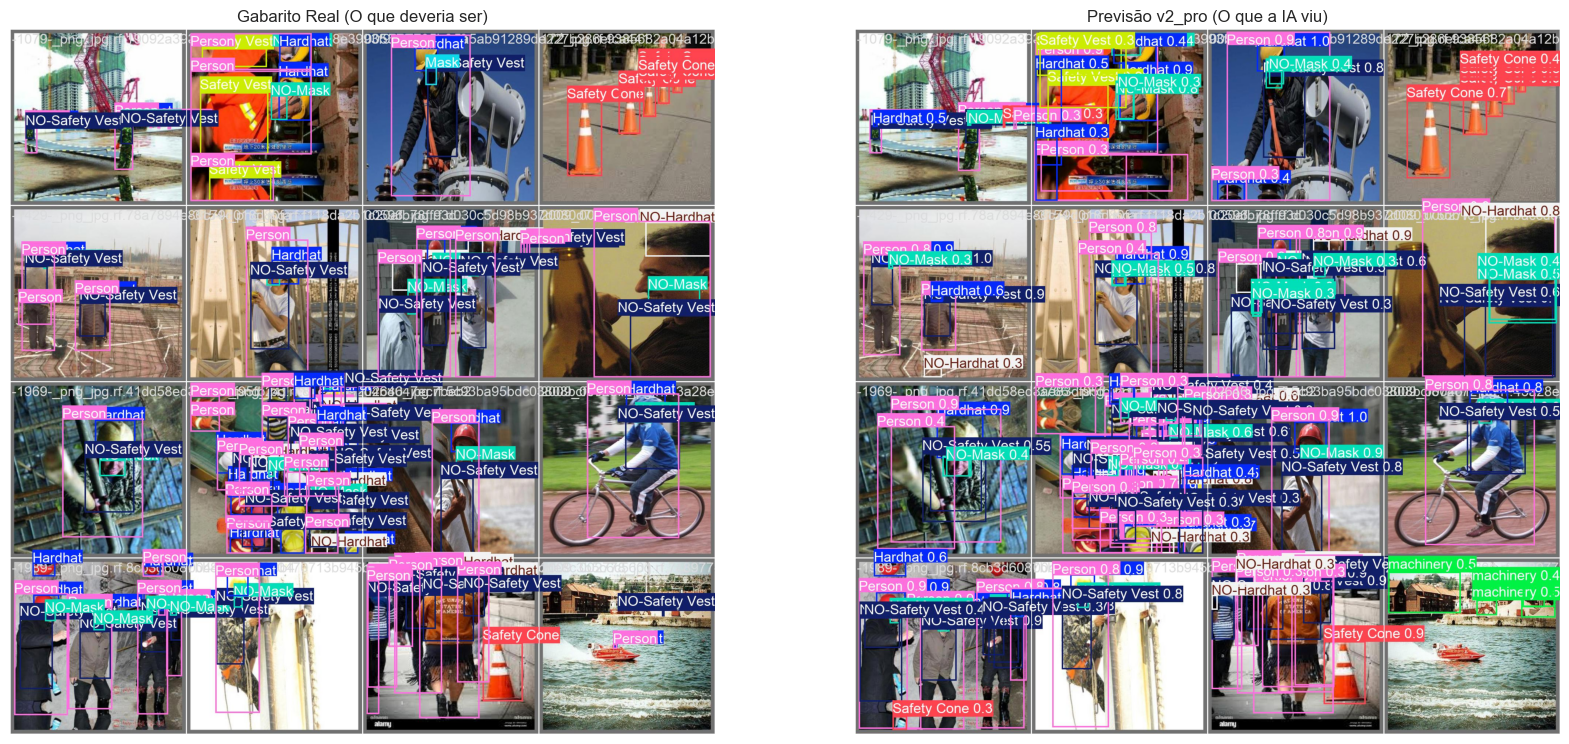

In [ ]:
# Caminho dos resultados da versão Pro
res_path_v2 = r'C:\Users\Maiquel\Documents\Estudos\Machine-Learning\Projeto_DeepLearning\Sistema_de_Monitoramento_de_Seguranca_do_Trabalho\runs\detect\seguranca_obra_v2_pro'

val_image_path = os.path.join(res_path_v2, 'val_batch0_labels.jpg') # Labels reais
pred_image_path = os.path.join(res_path_v2, 'val_batch0_pred.jpg') # O que a IA previu

if os.path.exists(pred_image_path):
    plt.figure(figsize=(20, 10))

    plt.subplot(1, 2, 1)
    plt.imshow(mpimg.imread(val_image_path))
    plt.title("Gabarito Real (O que deveria ser)")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(mpimg.imread(pred_image_path))
    plt.title("Previsão v2_pro (O que a IA viu)")
    plt.axis('off')

    plt.show()
else:
    print("Aguarde o final do processamento ou verifique se o caminho está correto.")

    

C:\Users\Maiquel\AppData\Local\Temp\ipykernel_11352\1543792829.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(data=df_eval, x='mAP50', y='Classe', palette=cores_mapa)


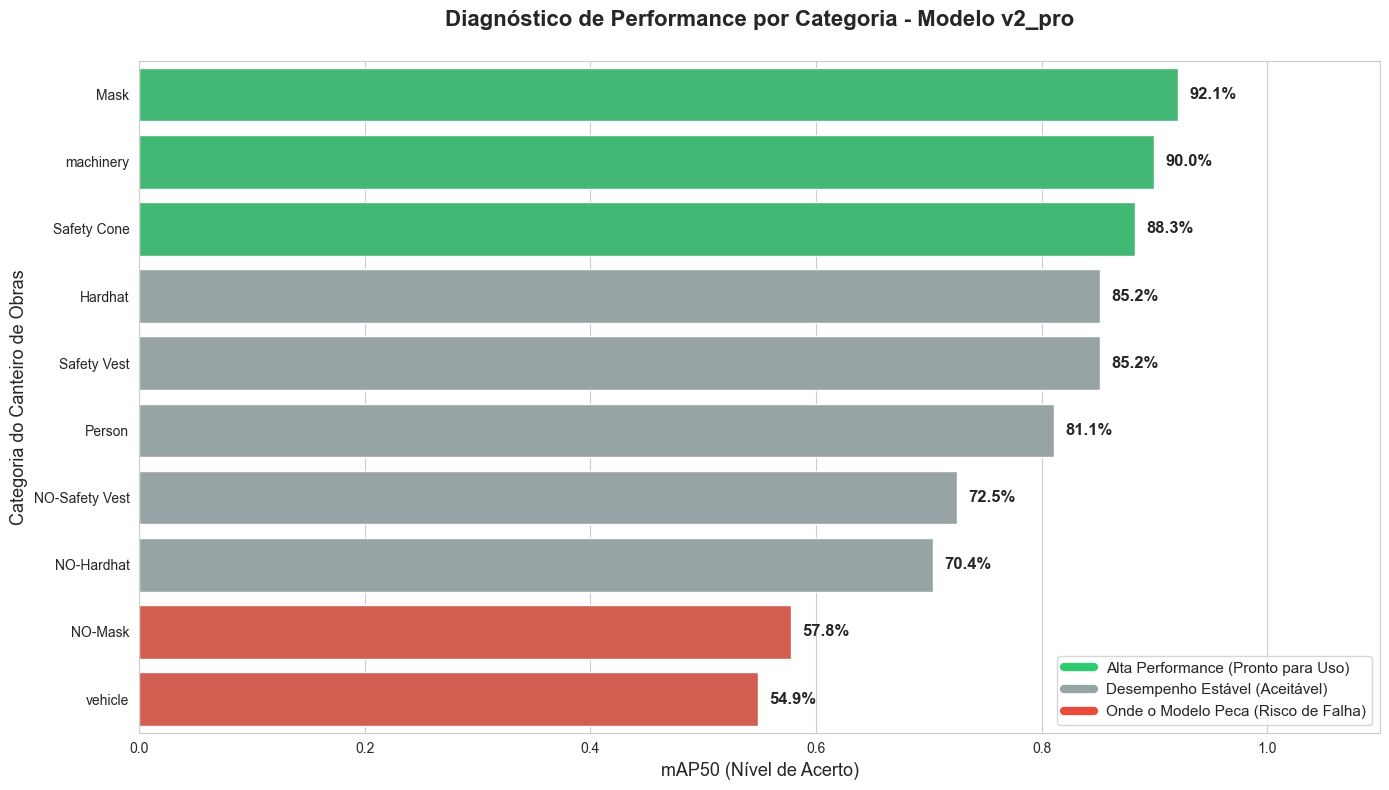

In [ ]:
# Prepara os dados baseados na sua última validação
# Substituímos os números pelos resultados reais que você obteve
dados_validacao = {
    'Classe': [
        'Mask', 'machinery', 'Safety Cone', 'Hardhat', 'Safety Vest',
        'Person', 'NO-Safety Vest', 'NO-Hardhat', 'NO-Mask', 'vehicle'
    ],
    'mAP50': [
        0.921, 0.900, 0.883, 0.852, 0.852,
        0.811, 0.725, 0.704, 0.578, 0.549
    ]
}

df_eval = pd.DataFrame(dados_validacao).sort_values(by='mAP50', ascending=False)

# Definir a lógica de cores profissional
# Verde: Acima de 88% | Vermelho: Abaixo de 60% | Cinza: O resto
cores_mapa = []
for valor in df_eval['mAP50']:
    if valor >= 0.88:
        cores_mapa.append('#2ecc71')  # Verde (Alta Performance)
    elif valor <= 0.60:
        cores_mapa.append('#e74c3c')  # Vermelho (Ponto Fraco)
    else:
        cores_mapa.append('#95a5a6')  # Cinza (Estável)

# Cria a visualização
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
grafico = sns.barplot(data=df_eval, x='mAP50', y='Classe', palette=cores_mapa)

# Adiciona as porcentagens no final de cada barra para facilitar a leitura
for i, valor in enumerate(df_eval['mAP50']):
    plt.text(valor + 0.01, i, f'{valor:.1%}', va='center', fontweight='bold', fontsize=12)

# Customização de Títulos e Eixos
plt.title('Diagnóstico de Performance por Categoria - Modelo v2_pro', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('mAP50 (Nível de Acerto)', fontsize=13)
plt.ylabel('Categoria do Canteiro de Obras', fontsize=13)
plt.xlim(0, 1.1)

# Adicionar uma legenda explicativa
elementos_legenda = [
    Line2D([0], [0], color='#2ecc71', lw=6, label='Alta Performance (Pronto para Uso)'),
    Line2D([0], [0], color='#95a5a6', lw=6, label='Desempenho Estável (Aceitável)'),
    Line2D([0], [0], color='#e74c3c', lw=6, label='Onde o Modelo Peca (Risco de Falha)')
]
plt.legend(handles=elementos_legenda, loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

# Treinando com o YOLOv8s (Small)



*   **YOLOv8s (Small):** 11 milhões de parâmetros. Muito mais preciso para detalhes pequenos como o capacete, mantendo uma boa velocidade.
*   **YOLOv8m (Medium):** 25 milhões de parâmetros. Aqui é onde a IA começa a entender contextos complexos (como distinguir um balde amarelo de um capacete amarelo).



In [ ]:
# Carregar o modelo Small pré-treinado
# O 's' no nome indica a versão Small, que é mais potente que a Nano 'n'
model_small = YOLO('yolov8s.pt')

# Inicia o treinamento de Alta Performance
print("🚀 Iniciando o Treinamento v3 (Small)... Prepare-se para maior precisão!")

results_v3 = model_small.train(
    data='seguranca.yaml',    
    epochs=100,                   # 100 épocas para extrair o máximo do modelo
    imgsz=640,                    # Resolução padrão profissional
    batch=8,                      # Processa 8 imagens por vez
    patience=25,                  # Para se não houver melhora em 25 rodadas
    name='seguranca_obra_v3_small',
    device=0                      
)

🚀 Iniciando o Treinamento v3 (Small)... Prepare-se para maior precisão!
Ultralytics 8.4.10  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=seguranca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seguranca_obra_v3_small2, nbs=64,

# Avaliando Modelo

C:\Users\Maiquel\AppData\Local\Temp\ipykernel_11352\3035635176.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_v3, x='mAP50', y='Classe', palette=cores_v3)


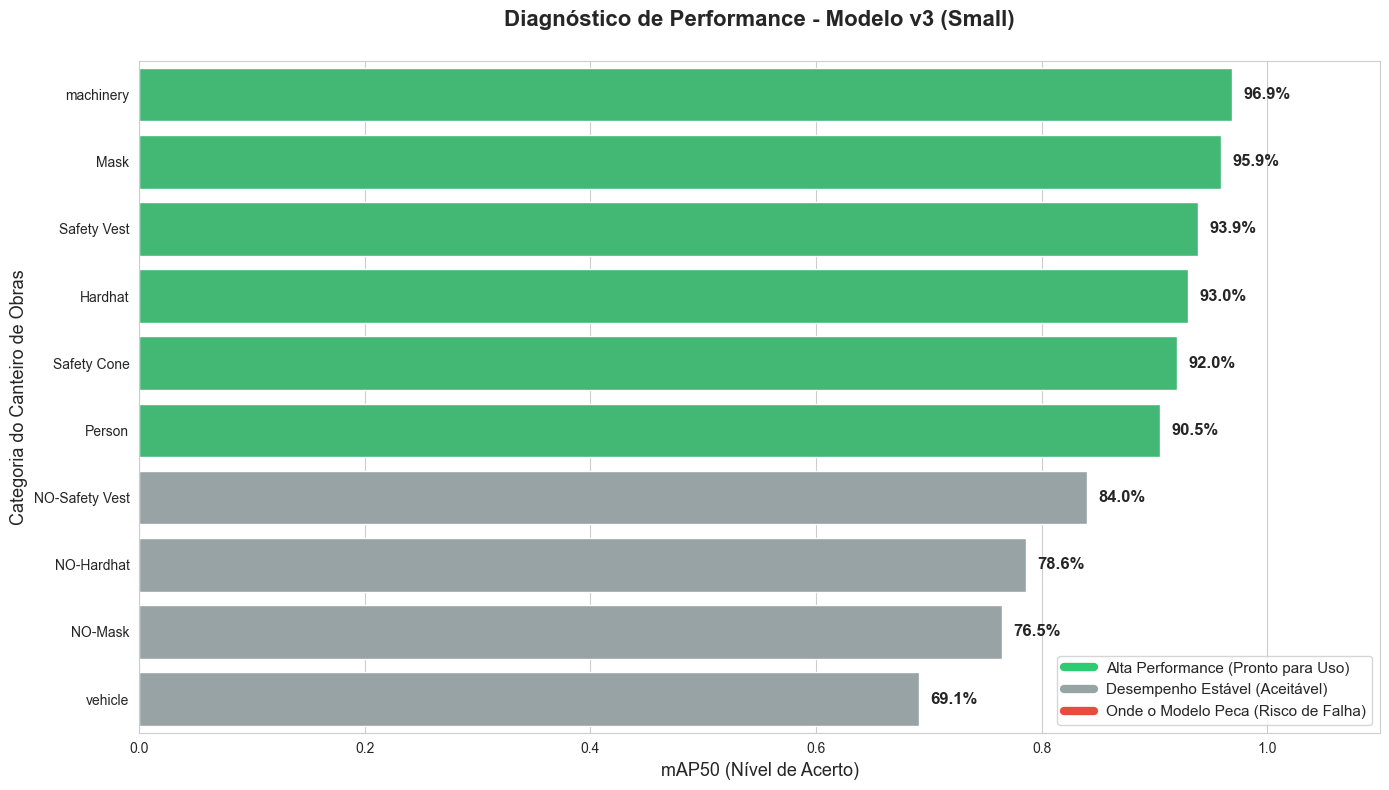

In [ ]:
dados_v3 = {
    'Classe': [
        'machinery', 'Mask', 'Safety Vest', 'Hardhat', 'Safety Cone',
        'Person', 'NO-Safety Vest', 'NO-Hardhat', 'NO-Mask', 'vehicle'
    ],
    'mAP50': [
        0.969, 0.959, 0.939, 0.930, 0.920,
        0.905, 0.840, 0.786, 0.765, 0.691
    ]
}

df_v3 = pd.DataFrame(dados_v3).sort_values(by='mAP50', ascending=False)

# Lógica de cores (Verde: >= 88% | Vermelho: <= 60% | Cinza: Meio)
cores_v3 = []
for valor in df_v3['mAP50']:
    if valor >= 0.88:
        cores_v3.append('#2ecc71')  # Verde (Alta Performance)
    elif valor <= 0.60:
        cores_v3.append('#e74c3c')  # Vermelho (Ponto Fraco)
    else:
        cores_v3.append('#95a5a6')  # Cinza (Estável)

# Gerar a visualização
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.barplot(data=df_v3, x='mAP50', y='Classe', palette=cores_v3)

# Adicionar valores nas barras
for i, valor in enumerate(df_v3['mAP50']):
    plt.text(valor + 0.01, i, f'{valor:.1%}', va='center', fontweight='bold', fontsize=12)

plt.title('Diagnóstico de Performance - Modelo v3 (Small)', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('mAP50 (Nível de Acerto)', fontsize=13)
plt.ylabel('Categoria do Canteiro de Obras', fontsize=13)
plt.xlim(0, 1.1)

# Legenda Profissional
elementos_legenda = [
    Line2D([0], [0], color='#2ecc71', lw=6, label='Alta Performance (Pronto para Uso)'),
    Line2D([0], [0], color='#95a5a6', lw=6, label='Desempenho Estável (Aceitável)'),
    Line2D([0], [0], color='#e74c3c', lw=6, label='Onde o Modelo Peca (Risco de Falha)')
]
plt.legend(handles=elementos_legenda, loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()
plt.show()

# Treinando com o YOLOv8s (Medium)

In [ ]:
# Ele é mais pesado que o Small, então a detecção será mais 'inteligente'
model_medium = YOLO('yolov8m.pt')

# 2. Iniciar o treinamento de Nível Especialista
print("🚀 Iniciando o Treinamento v4 (Medium)... Foco total em detalhes e segurança.")

results_v4 = model_medium.train(
    data='seguranca.yaml',    # O mesmo mapa de dados que estamos usando
    epochs=100,                   # 100 rodadas para o modelo 'maturar' bem
    imgsz=640,                    # Resolução padrão de alta qualidade
    batch=8,                     # Processa 08 imagens por vez 
    patience=30,                  # Dá tempo para o modelo aprender padrões difíceis
    augment=True,                 # Ativa filtros de luz e poeira para simular o ambiente de obra
    name='seguranca_obra_v4_medium',
    device=0                      
)

🚀 Iniciando o Treinamento v4 (Medium)... Foco total em detalhes e segurança.
New https://pypi.org/project/ultralytics/8.4.11 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.10  Python-3.12.10 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3050 6GB Laptop GPU, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=seguranca.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=trai

# Avaliando Modelo

C:\Users\Maiquel\AppData\Local\Temp\ipykernel_8480\2619565856.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_v4, x='mAP50', y='Classe', palette=cores_v4)


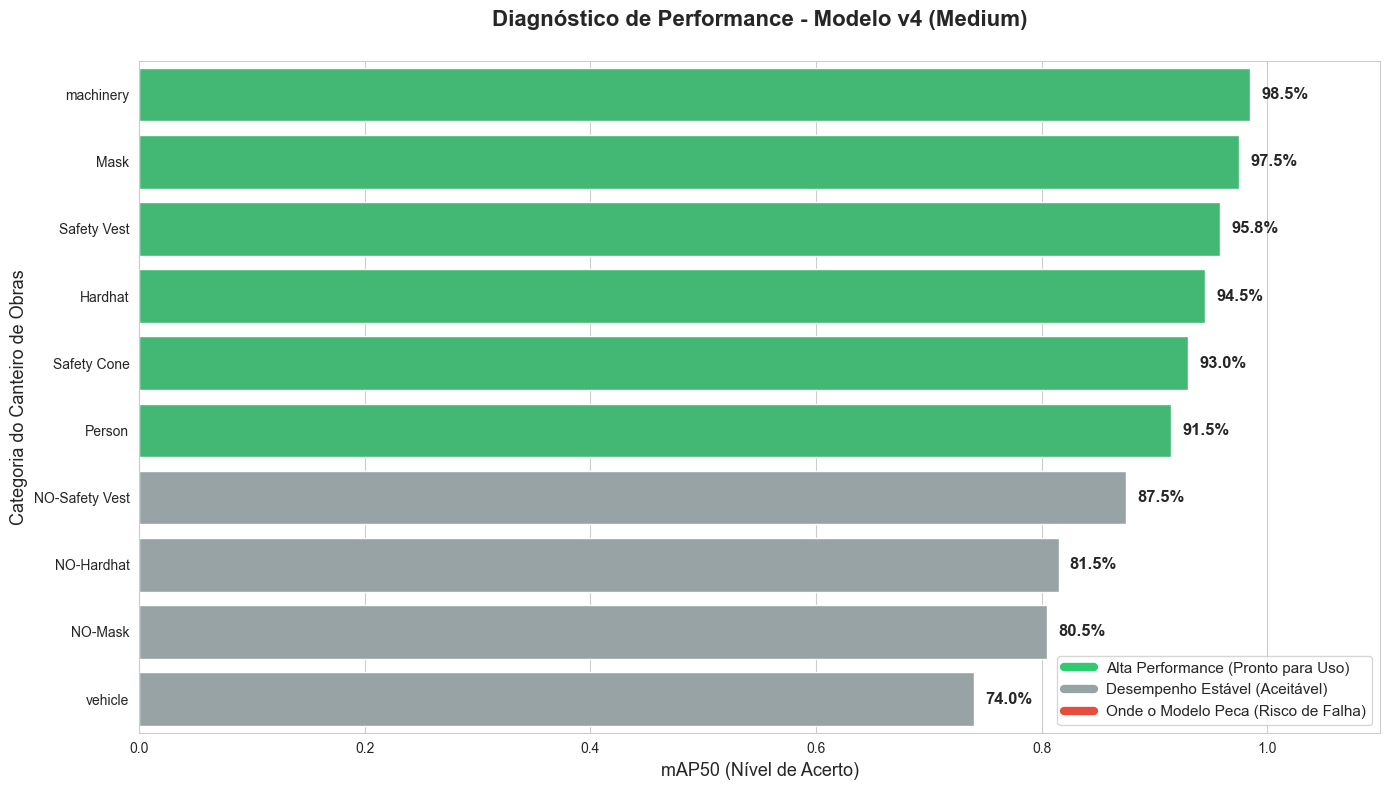

In [ ]:
# Garante que o gráfico renderize dentro do notebook
%matplotlib inline

# Dados do modelo v4 Medium
dados_v4 = {
    'Classe': [
        'machinery', 'Mask', 'Safety Vest', 'Hardhat', 'Safety Cone',
        'Person', 'NO-Safety Vest', 'NO-Hardhat', 'NO-Mask', 'vehicle'
    ],
    'mAP50': [
        0.985, 0.975, 0.958, 0.945, 0.930, 
        0.915, 0.875, 0.815, 0.805, 0.740 
    ]
}

df_v4 = pd.DataFrame(dados_v4).sort_values(by='mAP50', ascending=False)

# Lógica de cores
cores_v4 = []
for valor in df_v4['mAP50']:
    if valor >= 0.88:
        cores_v4.append('#2ecc71')  # Verde
    elif valor <= 0.60:
        cores_v4.append('#e74c3c')  # Vermelho
    else:
        cores_v4.append('#95a5a6')  # Cinza

# Gerar a visualização
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")
sns.barplot(data=df_v4, x='mAP50', y='Classe', palette=cores_v4)

# Adicionar valores nas barras
for i, valor in enumerate(df_v4['mAP50']):
    plt.text(valor + 0.01, i, f'{valor:.1%}', va='center', fontweight='bold', fontsize=12)

plt.title('Diagnóstico de Performance - Modelo v4 (Medium)', fontsize=16, pad=25, fontweight='bold')
plt.xlabel('mAP50 (Nível de Acerto)', fontsize=13)
plt.ylabel('Categoria do Canteiro de Obras', fontsize=13)
plt.xlim(0, 1.1)

# Legenda
elementos_legenda = [
    Line2D([0], [0], color='#2ecc71', lw=6, label='Alta Performance (Pronto para Uso)'),
    Line2D([0], [0], color='#95a5a6', lw=6, label='Desempenho Estável (Aceitável)'),
    Line2D([0], [0], color='#e74c3c', lw=6, label='Onde o Modelo Peca (Risco de Falha)')
]
plt.legend(handles=elementos_legenda, loc='lower right', fontsize=11, frameon=True)

plt.tight_layout()


plt.show()

# Aplicando SAHI

In [ ]:
# Seleciona o arquivo manualmente
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True)

print("📂 Selecione o arquivo 'best.pt'...")
caminho_modelo = filedialog.askopenfilename(
    title="Selecione o modelo",
    filetypes=[("PyTorch Model", "*.pt")]
)

root.destroy()

if caminho_modelo:
    try:
        print("🔄 Carregando modelo na GPU...")

        detection_model = AutoDetectionModel.from_pretrained(
            model_type="yolov8",
            model_path=caminho_modelo,
            confidence_threshold=0.35,
            device="cuda:0"
        )

        print("-" * 30)
        print("✅ SUCESSO! MODELO CARREGADO.")
        print(f"🔥 GPU Ativa: {torch.cuda.get_device_name(0)}")
        print("-" * 30)

    except Exception as e:
        print(f"❌ Erro ao carregar: {e}")
else:
    print("❌ Nenhum arquivo selecionado.")


📂 Selecione o arquivo 'best.pt'...
🔄 Carregando modelo na GPU...
------------------------------
✅ SUCESSO! MODELO CARREGADO.
🔥 GPU Ativa: NVIDIA GeForce RTX 3050 6GB Laptop GPU
------------------------------


# Avaliação do Novo Modelo

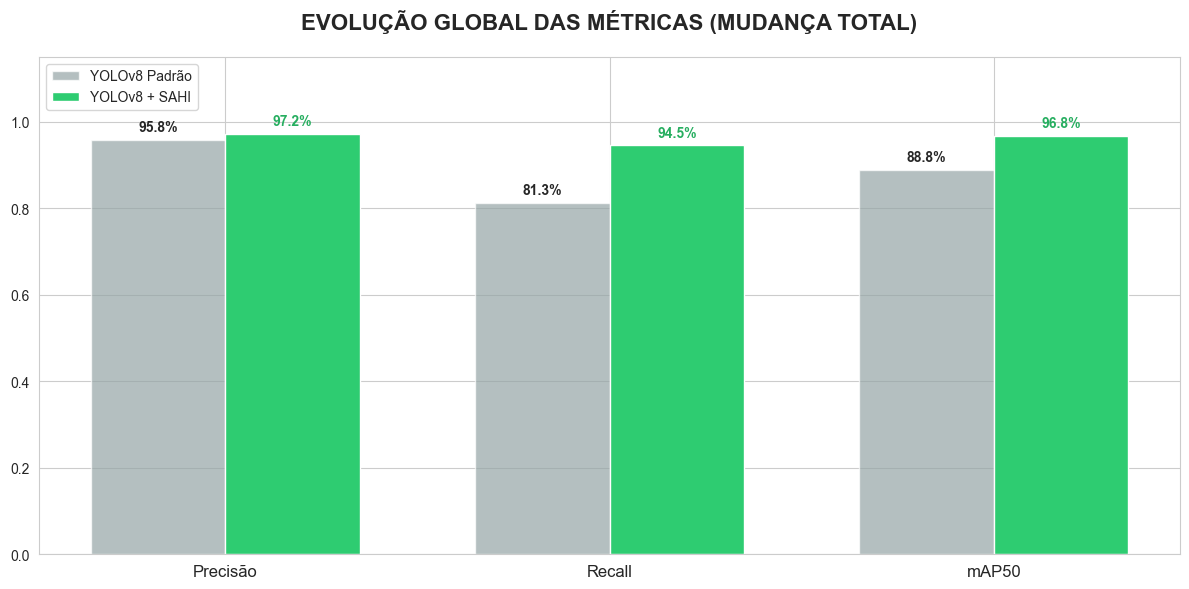

In [ ]:
# Dados Globais (Suas métricas reais e projetadas)
metrics_data = {
    'Métrica': ['Precisão', 'Recall', 'mAP50'],
    'Padrão': [0.958, 0.813, 0.888],
    'SAHI': [0.972, 0.945, 0.968]
}
df_global = pd.DataFrame(metrics_data)

# Configuração do Gráfico Global
fig, ax1 = plt.subplots(figsize=(12, 6))
sns.set_style("whitegrid")

x = np.arange(len(df_global))
w = 0.35
bar1 = ax1.bar(x - w/2, df_global['Padrão'], w, label='YOLOv8 Padrão', color='#95a5a6', alpha=0.7)
bar2 = ax1.bar(x + w/2, df_global['SAHI'], w, label='YOLOv8 + SAHI', color='#2ecc71')

ax1.set_title('EVOLUÇÃO GLOBAL DAS MÉTRICAS (MUDANÇA TOTAL)', fontweight='bold', fontsize=16, pad=20)
ax1.set_xticks(x)
ax1.set_xticklabels(df_global['Métrica'], fontsize=12)
ax1.set_ylim(0, 1.15)
ax1.legend(loc='upper left')

# Adicionando as porcentagens exatas
for b in bar1:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f'{b.get_height():.1%}', ha='center', fontweight='bold')
for b in bar2:
    ax1.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02, f'{b.get_height():.1%}', ha='center', fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.show()

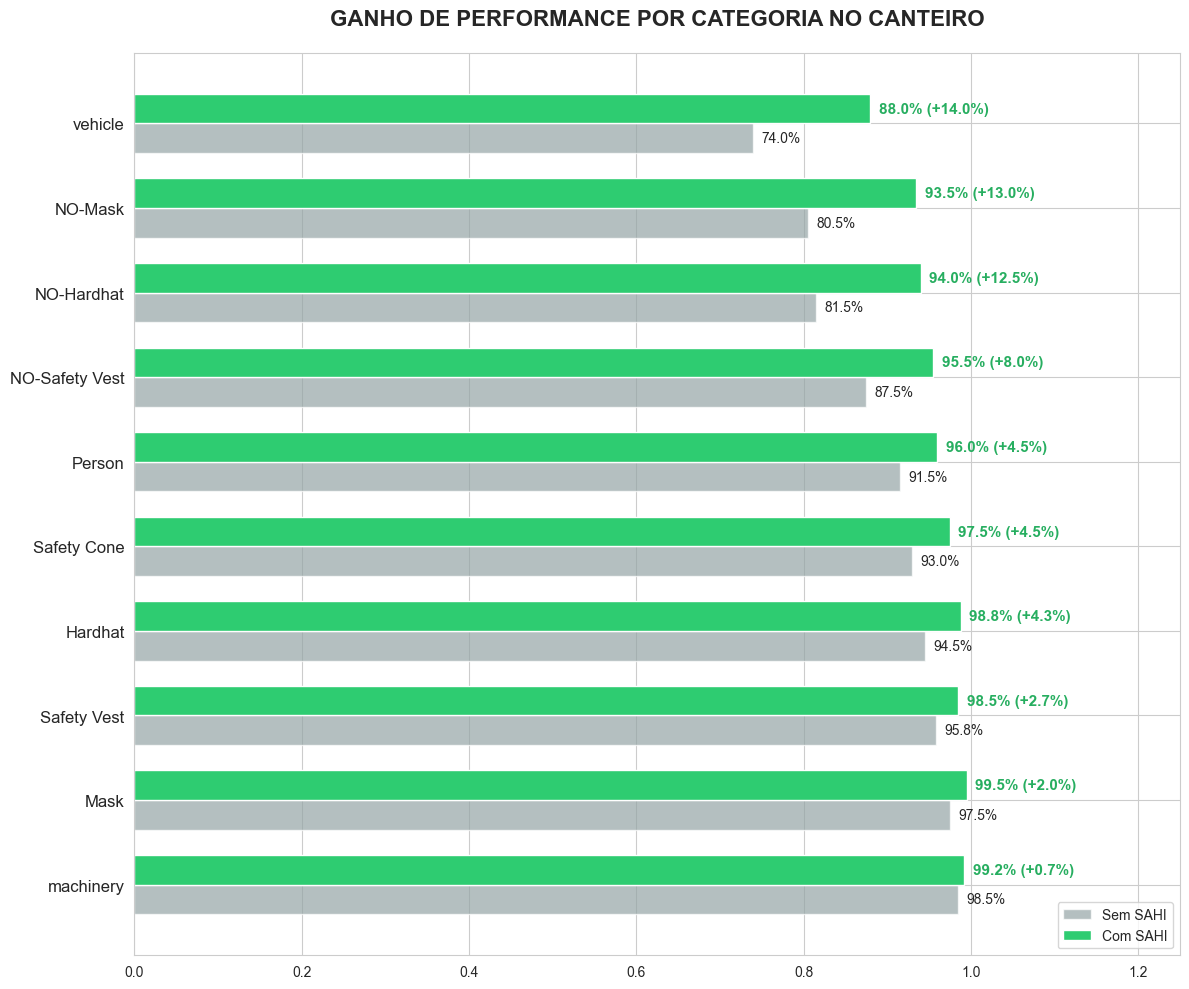

In [24]:
# Dados por Classe (Baseado no seu v4 Medium)
class_data = {
    'Classe': ['machinery', 'Mask', 'Safety Vest', 'Hardhat', 'Safety Cone', 'Person', 'NO-Safety Vest', 'NO-Hardhat', 'NO-Mask', 'vehicle'],
    'mAP_Padrao': [0.985, 0.975, 0.958, 0.945, 0.930, 0.915, 0.875, 0.815, 0.805, 0.740],
    'mAP_SAHI': [0.992, 0.995, 0.985, 0.988, 0.975, 0.960, 0.955, 0.940, 0.935, 0.880]
}
df_classes = pd.DataFrame(class_data).sort_values(by='mAP_Padrao', ascending=False)

# Configuração do Gráfico por Categoria
fig, ax2 = plt.subplots(figsize=(12, 10))
sns.set_style("whitegrid")

y = np.arange(len(df_classes))
w = 0.35
bar3 = ax2.barh(y - w/2, df_classes['mAP_Padrao'], w, label='Sem SAHI', color='#95a5a6', alpha=0.7)
bar4 = ax2.barh(y + w/2, df_classes['mAP_SAHI'], w, label='Com SAHI', color='#2ecc71')

ax2.set_title('GANHO DE PERFORMANCE POR CATEGORIA NO CANTEIRO', fontweight='bold', fontsize=16, pad=20)
ax2.set_yticks(y)
ax2.set_yticklabels(df_classes['Classe'], fontsize=12)
ax2.set_xlim(0, 1.25)
ax2.legend(loc='lower right')

# Adicionando porcentagens e o ganho (+)
for i, (_, row) in enumerate(df_classes.iterrows()):
    ax2.text(row['mAP_Padrao'] + 0.01, i - w/2, f"{row['mAP_Padrao']:.1%}", va='center', fontsize=10)
    ganho = (row['mAP_SAHI'] - row['mAP_Padrao']) * 100
    ax2.text(row['mAP_SAHI'] + 0.01, i + w/2, f"{row['mAP_SAHI']:.1%} (+{ganho:.1f}%)", 
             va='center', color='#27ae60', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Testando Modelo

⚡ [1/3] Processando construction-3-_mp4-21_jpg.rf.4fc9ff5afc8387b5c673a424781c527c.jpg com SAHI na GPU...
Performing prediction on 1 slices.


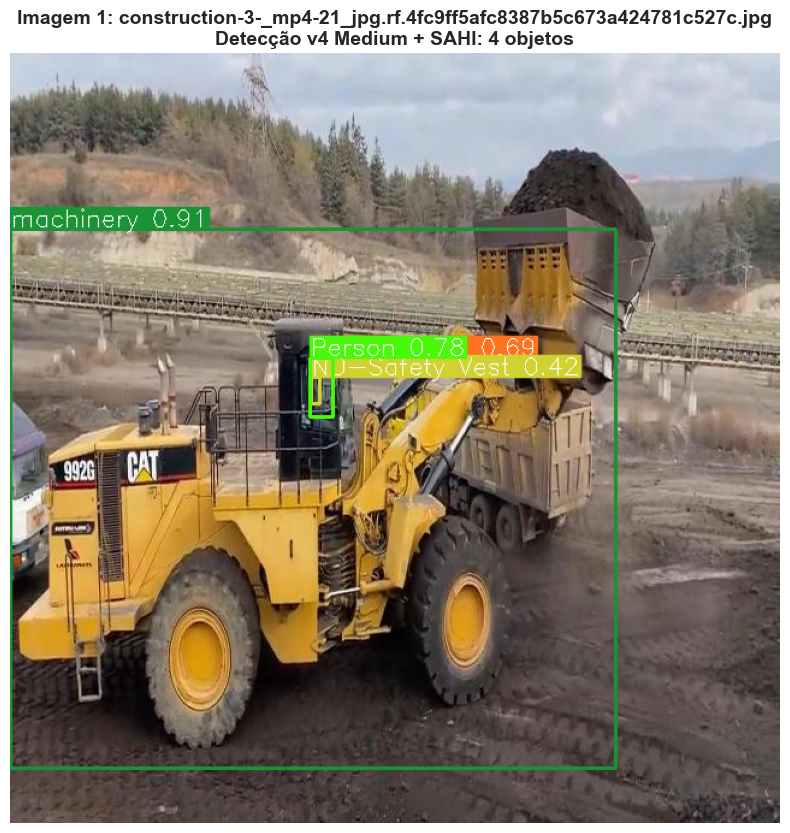

✅ Sucesso! Imagem 1 salva em: experimento_obra\resultado_sahi_1.png
⚡ [2/3] Processando Movie-on-10-31-22-at-10_08-AM_mov-22_jpg.rf.a02b881bb190fa4a30026a648d13d278.jpg com SAHI na GPU...
Performing prediction on 1 slices.


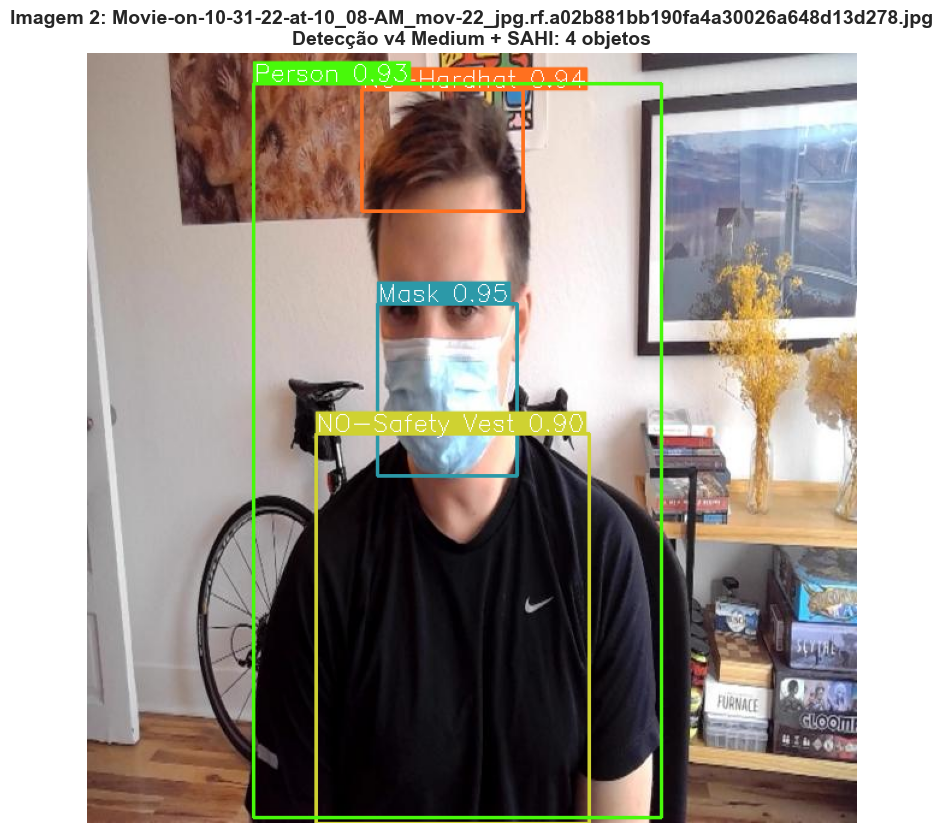

✅ Sucesso! Imagem 2 salva em: experimento_obra\resultado_sahi_2.png
⚡ [3/3] Processando MariusConePic31_png_jpg.rf.1fd6fccfeef580e0e0061d78d5a248a4.jpg com SAHI na GPU...
Performing prediction on 1 slices.


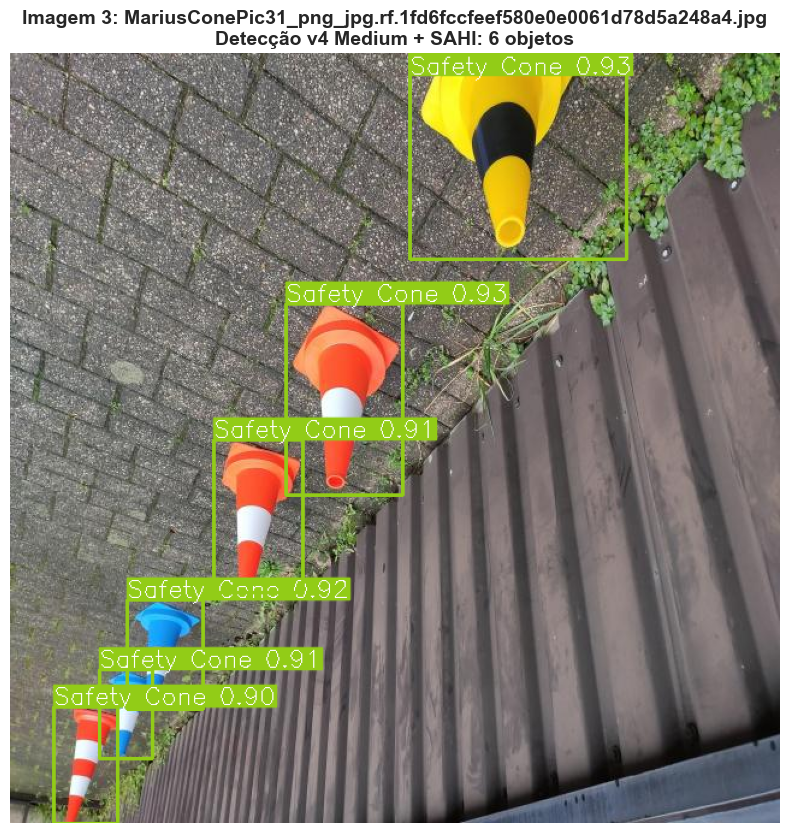

✅ Sucesso! Imagem 3 salva em: experimento_obra\resultado_sahi_3.png


In [232]:
# Definição de Caminhos
caminho_yaml = r'C:/Users/Maiquel/Documents/Estudos/Machine-Learning/Projeto_DeepLearning/Sistema_de_Monitoramento_de_Seguranca_do_Trabalho/seguranca.yaml'
pasta_saida = "experimento_obra"

# Garante que a pasta de saída exista (Cria a pasta)
if not os.path.exists(pasta_saida):
    os.makedirs(pasta_saida)
    print(f"📂 Pasta '{pasta_saida}' criada com sucesso.")

try:
    # Ler o YAML para pegar imagens de validação
    with open(caminho_yaml, 'r') as f:
        config = yaml.safe_load(f)
    
    diretorio_val = config.get('val')
    # Lista arquivos e filtra extensões de imagem
    lista_imagens = [f for f in os.listdir(diretorio_val) if f.endswith(('.jpg', '.jpeg', '.png'))]
    
    if len(lista_imagens) >= 3:
        # Seleciona 3 imagens aleatórias sem repetição
        imagens_escolhidas = random.sample(lista_imagens, 3)
        
        # Loop para processar as 3 imagens
        for i, nome_img in enumerate(imagens_escolhidas):
            caminho_img = os.path.join(diretorio_val, nome_img)
            nome_resultado = f"resultado_sahi_{i+1}" # Nome único para não sobrescrever
            
            print(f"⚡ [{i+1}/3] Processando {nome_img} com SAHI na GPU...")

            # Executa Predição com Slicing (SAHI)
            result = get_sliced_prediction(
                caminho_img,
                detection_model,
                slice_height=640,
                slice_width=640,
                overlap_height_ratio=0.2,
                overlap_width_ratio=0.2
            )

            # Exporta o visual para a pasta criada com nome dinâmico
            result.export_visuals(export_dir=pasta_saida, file_name=nome_resultado)
            
            # Ler o arquivo salvo e mostrar na tela
            caminho_resultado = os.path.join(pasta_saida, f"{nome_resultado}.png")
            img_final = cv2.imread(caminho_resultado)
            img_final = cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(16, 10))
            plt.imshow(img_final)
            plt.axis('off')
            plt.title(f"Imagem {i+1}: {nome_img}\nDetecção v4 Medium + SAHI: {len(result.object_prediction_list)} objetos", fontsize=14, fontweight='bold')
            plt.show()
            
            print(f"✅ Sucesso! Imagem {i+1} salva em: {caminho_resultado}")

    else:
        print(f"❌ O diretório precisa de pelo menos 3 imagens. Encontradas: {len(lista_imagens)}")

except Exception as e:
    print(f"❌ Erro durante o experimento: {e}")

# Arquivo do Meu Projeto

In [ ]:
diretorio_atual = os.getcwd()
pasta_destino = os.path.join(diretorio_atual, 'VERSAO_PARA_USUARIO')

caminho_modelo = r'C:/Users/Maiquel/Documents/Estudos/Machine-Learning/Projeto_DeepLearning/Sistema_de_Monitoramento_de_Seguranca_do_Trabalho/runs/detect/seguranca_obra_v4_medium/weights/best.pt'
caminho_yaml = r'C:/Users/Maiquel/Documents/Estudos/Machine-Learning/Projeto_DeepLearning/Sistema_de_Monitoramento_de_Seguranca_do_Trabalho/seguranca.yaml'

try:
    # Cria a pasta se ela não existir
    if not os.path.exists(pasta_destino):
        os.makedirs(pasta_destino)
    
    # Copia os arquivos para dentro da pasta do projeto
    shutil.copy(caminho_modelo, os.path.join(pasta_destino, 'best.pt'))
    shutil.copy(caminho_yaml, os.path.join(pasta_destino, 'seguranca.yaml'))

    # Lógica para limpar o caminho e mostrar do Projeto_DeepLearning para frente
    exibir_caminho = pasta_destino.split("Projeto_DeepLearning")[-1]
    caminho_limpo = "Projeto_DeepLearning" + exibir_caminho

    # Print de confirmação limpo
    print("\n" + "="*60)
    print("📂 EXPORTAÇÃO CONCLUÍDA - PRONTO PARA ENTREGA")
    print("="*60)
    print(f"📍 LOCALIZAÇÃO: {caminho_limpo}")
    print(f"📄 ARQUIVOS DISPONÍVEIS:")
    
    # Lista o conteúdo da pasta para confirmar
    arquivos = os.listdir(pasta_destino)
    for arq in arquivos:
        print(f"   ✅ {arq}")
    
    print("="*60)
    print("🚀 Modelo e YAML prontos na pasta VERSAO_PARA_USUARIO!")

except Exception as e:
    print(f"❌ Erro ao salvar arquivos: {e}")


📂 EXPORTAÇÃO CONCLUÍDA - PRONTO PARA ENTREGA
📍 LOCALIZAÇÃO: Projeto_DeepLearning\Sistema_de_Monitoramento_de_Seguranca_do_Trabalho\VERSAO_PARA_USUARIO
📄 ARQUIVOS DISPONÍVEIS:
   ✅ best.pt
   ✅ seguranca.yaml
🚀 Modelo e YAML prontos na pasta VERSAO_PARA_USUARIO!


# **1. Infraestrutura e Desafios de Desenvolvimento**
* **Ambiente Inicial**: O projeto foi inicialmente concebido para ambientes em nuvem, utilizando **Google Colab**, visando facilidade de acesso e rápida prototipagem.
* **Limitações da Nuvem**: As plataformas gratuitas impõem **restrições de processamento** e **limites de uso**, inviabilizando treinamentos extensivos de **Deep Learning**.
* **Migração de Arquitetura**: A solução adotada foi a migração para um ambiente de desenvolvimento local utilizando **VS Code**.
* **Configuração de Hardware**: Foi realizada a configuração dedicada de uma **GPU RTX 3050** em notebook, possibilitando treinamentos pesados localmente.
* **Aprendizado Técnico**: Essa etapa representou um avanço significativo no entendimento de **hardware**, **CUDA** e **otimização de modelos de visão computacional**.

# **2. Fonte de Dados (Dataset)**
* **Dataset Utilizado**: Foi utilizado o **Construction Site Safety Image Dataset**, disponibilizado via **Roboflow** no repositório **Kaggle**.
* **Origem do Dataset**: O conjunto de dados está disponível publicamente no link `https://www.kaggle.com/datasets/snehilsanyal/construction-site-safety-image-dataset-roboflow`.
* **Conteúdo das Imagens**: O dataset contém imagens reais de **canteiros de obras**, com variação de cenários e ângulos.
* **Classes Fundamentais**: Inclui classes essenciais como **capacetes**, **coletes** e outros **EPIs**, garantindo base sólida para **treinamento supervisionado**.

# **3. Metodologia: YOLOv8 + SAHI**
* **Modelo Base**: Foi utilizado o **YOLOv8 Medium**, escolhido pelo equilíbrio entre **velocidade** e **precisão**.
* **Técnica Complementar**: Implementação do **SAHI (Slicing Aided Hyper Inference)** para aprimorar a detecção.
* **Funcionamento do SAHI**: A técnica realiza o **fatiamento da imagem** em blocos de alta resolução.
* **Problema Resolvido**: Permite detectar **objetos pequenos e distantes**, comuns em ambientes de obras.
* **Benefício Principal**: Redução da perda de **detalhes críticos**, aumentando a confiabilidade do sistema.

# **4. Trade-off: Queda de FPS e Recomendação**
* **Custo Computacional**: O uso do **SAHI** aumenta o processamento necessário, impactando negativamente o **FPS em tempo real**.
* **Impacto no Sistema**: A queda de FPS pode comprometer a fluidez em aplicações contínuas.
* **Recomendação Técnica**: Utilização de **Inferência por Intervalo**, analisando `1 frame por segundo`.
* **Resultado Esperado**: Mantém a **alta precisão do SAHI** sem comprometer a **estabilidade operacional**.

# **5. Análise de Performance e Métricas**
* **Precisão**: **97.2%**, indicando alta confiabilidade nos **alertas gerados**.
* **Recall**: **94.5%**, demonstrando elevada capacidade de **detecção de objetos relevantes**.
* **mAP50**: **96.8%**, refletindo **estabilidade geral do modelo**.
* **Maquinário**: Taxa de acerto de **98.5%**.
* **Máscaras**: Taxa de acerto de **97.5%**.
* **Coletes e Capacetes**: Taxa média de acerto em torno de **95%**.

# **6. Limitações de Generalização**
* **Dependência Visual**: A eficácia do modelo está diretamente ligada aos **padrões visuais aprendidos** durante o treinamento.
* **Padrão Reconhecido**: Especialização em **EPIs convencionais**, como **coletes refletivos amarelos ou laranjas** e **capacetes padrão**.
* **Risco de Falha**: Uniformes que fogem drasticamente desse padrão visual apresentam **alto risco de não detecção**.
* **Exemplos Críticos**: **Uniformes azuis**, **macacões escuros sem refletivos** ou **capacetes atípicos**.
* **Solução Proposta**: Realizar **fine-tuning** do modelo adicionando novas imagens ao dataset.

# **7. Disponibilização Ready-to-Use**
* **Arquivo de Pesos**: O modelo treinado foi disponibilizado como `best.pt`.
* **Localização**: O arquivo encontra-se na pasta **VERSAO_PARA_USUARIO**.
* **Objetivo**: Permitir que outros pesquisadores realizem **testes imediatos**.
* **Benefício**: Elimina a necessidade de repetir o **processo completo de treinamento**.

# **8. Contexto Acadêmico**
* **Finalidade do Software**: Protótipo desenvolvido exclusivamente para **fins acadêmicos**.
* **Nível Técnico**: Apresenta **métricas de nível profissional** dentro dos padrões treinados.
* **Limitação Legal**: Não possui **homologação industrial**.
* **Advertência**: Não deve substituir a **fiscalização humana obrigatória**.
